# Sensitivity analysis simplified vs full range

                Full Mean  Simplified Mean  Difference
min              6.343893         6.234064   -0.109829
lower_quantile   6.827967         6.250423   -0.577544
median           7.479994         7.477436   -0.002558
upper_quantile   8.260833         9.281469    1.020636
max              9.079549         9.305824    0.226275


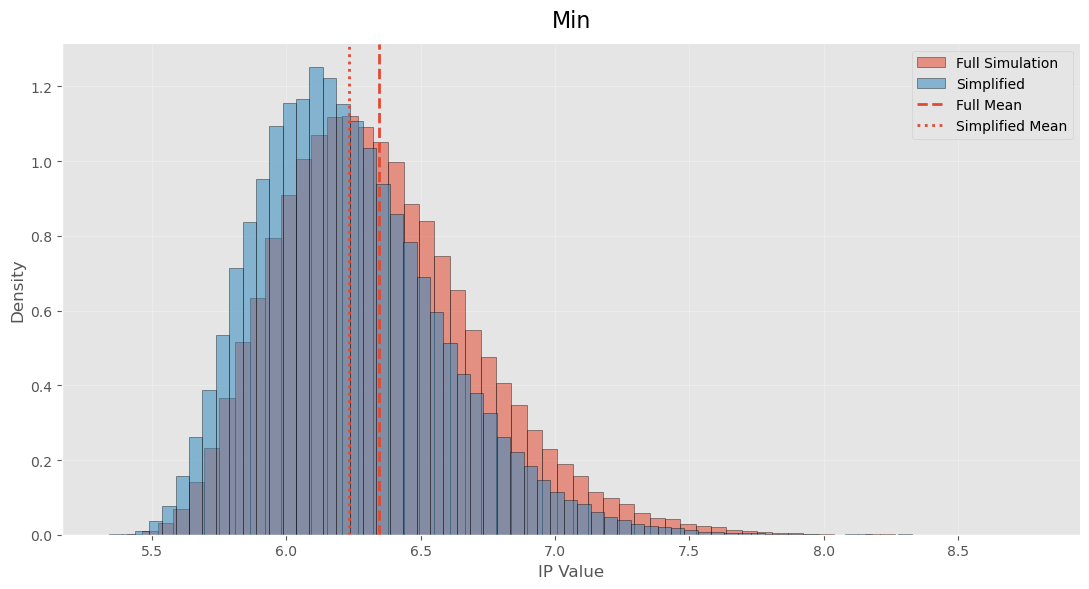

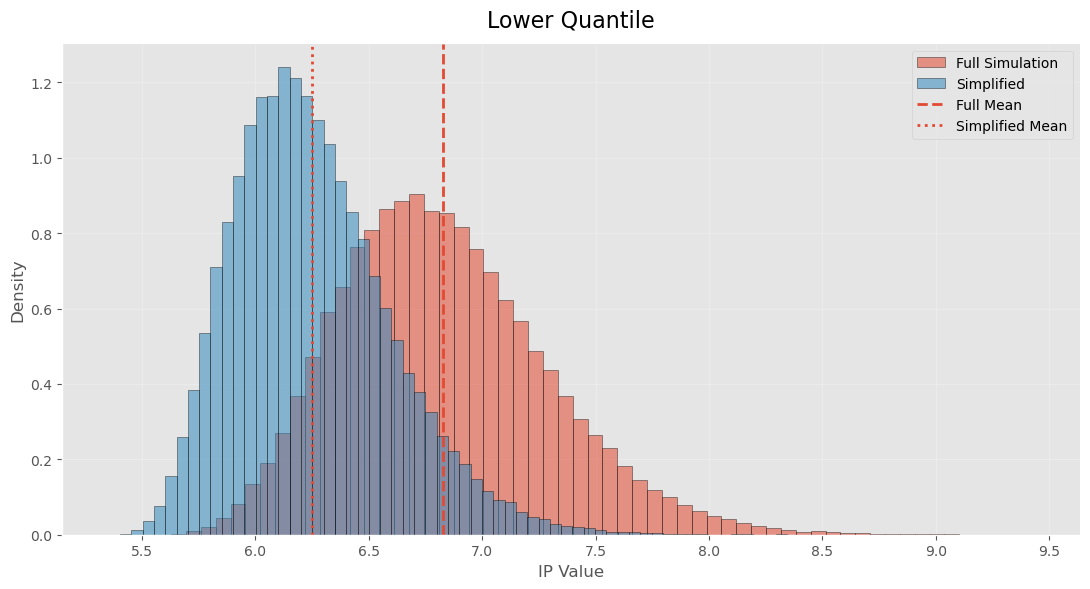

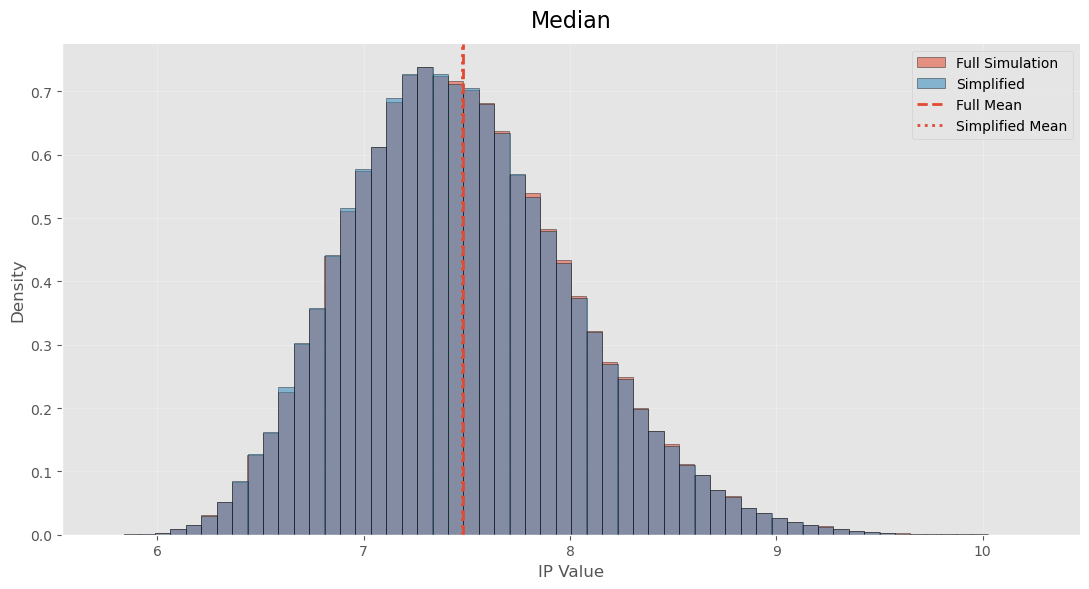

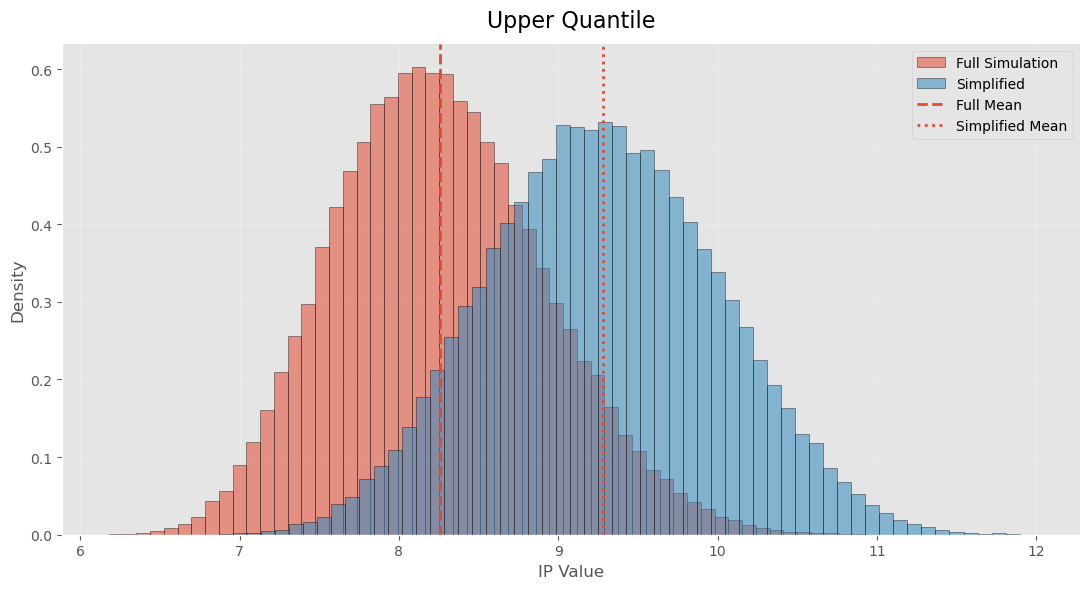

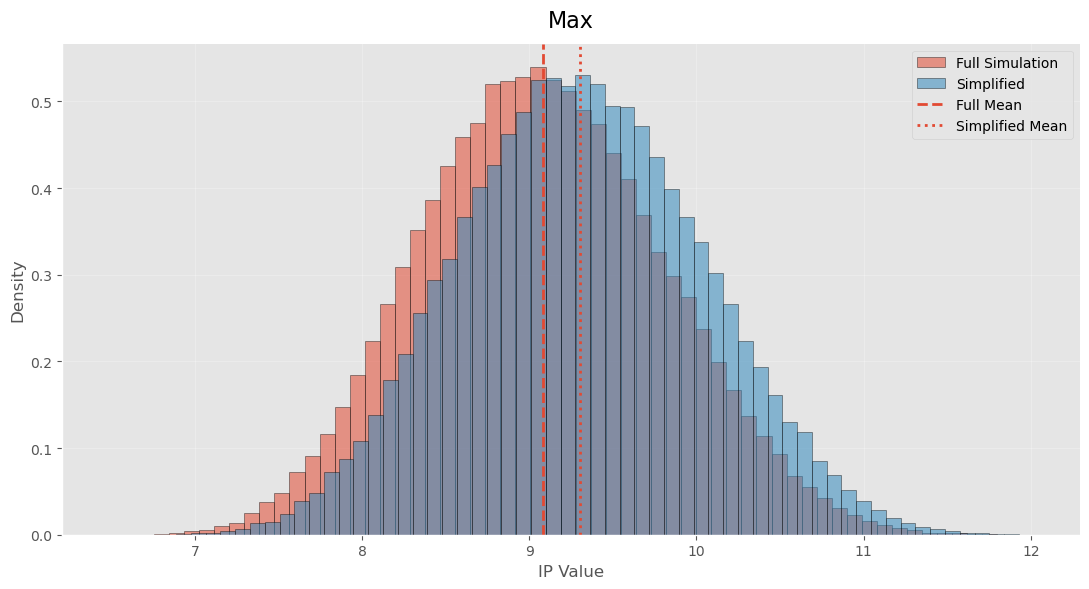

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

def ip_value(
    growth_rate,
    interest_rate,
    routine_return_rate,
    rnd_pct,
    initial_income=1,
    years=100
):
    t = np.arange(1, years + 1)
    income = initial_income * (1 + growth_rate) ** (t - 1)
    rnd_cost = rnd_pct * income
    cash_flow = income - rnd_cost - routine_return_rate * rnd_cost
    pv = np.sum(cash_flow / (1 + interest_rate) ** t)
    return pv

def summary_stats(x):
    return {
        "min": np.min(x),
        "lower_quantile": np.quantile(x, 0.25),
        "median": np.median(x),
        "upper_quantile": np.quantile(x, 0.75),
        "max": np.max(x)
    }

def run_full_simulation(
    n_draws=30,
    rr_low=0.05,
    rr_high=0.10,
    ir_low=0.10,
    ir_high=0.20,
    growth_rate=0.03,
    rnd_pct=0.10,
    initial_income=1,
    years=100
):
    rr = np.random.uniform(rr_low, rr_high, n_draws)
    ir = np.random.uniform(ir_low, ir_high, n_draws)

    rr_iqr = rr[(rr >= np.quantile(rr, 0.25)) & (rr <= np.quantile(rr, 0.75))]
    ir_iqr = ir[(ir >= np.quantile(ir, 0.25)) & (ir <= np.quantile(ir, 0.75))]

    vals = []

    for r in rr_iqr:
        for i in ir_iqr:
            vals.append(
                ip_value(
                    growth_rate,
                    i,
                    r,
                    rnd_pct,
                    initial_income,
                    years
                )
            )

    vals = np.array(vals)
    return summary_stats(vals), rr, ir

def run_simplified_simulation(
    rr,
    ir,
    growth_rate=0.03,
    rnd_pct=0.10,
    initial_income=1,
    years=100
):
    rr_pts = np.quantile(rr, [0.25, 0.50, 0.75])
    ir_pts = np.quantile(ir, [0.25, 0.50, 0.75])

    vals = []

    for r in rr_pts:
        for i in ir_pts:
            vals.append(
                ip_value(
                    growth_rate,
                    i,
                    r,
                    rnd_pct,
                    initial_income,
                    years
                )
            )

    vals = np.array(vals)
    return summary_stats(vals)

def monte_carlo(
    reps=100000,
    n_draws=30,
    rr_low=0.05,
    rr_high=0.10,
    ir_low=0.10,
    ir_high=0.20,
    growth_rate=0.03,
    rnd_pct=0.10,
    initial_income=1,
    years=100
):
    full_results = []
    simple_results = []

    for _ in range(reps):
        full_stat, rr, ir = run_full_simulation(
            n_draws,
            rr_low,
            rr_high,
            ir_low,
            ir_high,
            growth_rate,
            rnd_pct,
            initial_income,
            years
        )

        simple_stat = run_simplified_simulation(
            rr,
            ir,
            growth_rate,
            rnd_pct,
            initial_income,
            years
        )

        full_results.append(full_stat)
        simple_results.append(simple_stat)

    full_df = pd.DataFrame(full_results)
    simple_df = pd.DataFrame(simple_results)

    compare = pd.DataFrame({
        "Full Mean": full_df.mean(),
        "Simplified Mean": simple_df.mean(),
        "Difference": simple_df.mean() - full_df.mean()
    })

    return full_df, simple_df, compare

full_df, simple_df, compare = monte_carlo()

print(compare)

metrics = ["min", "lower_quantile", "median", "upper_quantile", "max"]

for m in metrics:
    fig, ax = plt.subplots(figsize=(11, 6))

    ax.hist(
        full_df[m],
        bins=60,
        alpha=0.55,
        density=True,
        edgecolor="black",
        linewidth=0.5,
        label="Full Simulation"
    )

    ax.hist(
        simple_df[m],
        bins=60,
        alpha=0.55,
        density=True,
        edgecolor="black",
        linewidth=0.5,
        label="Simplified"
    )

    ax.axvline(full_df[m].mean(), linestyle="--", linewidth=2, label="Full Mean")
    ax.axvline(simple_df[m].mean(), linestyle=":", linewidth=2, label="Simplified Mean")

    ax.set_title(m.replace("_", " ").title(), fontsize=16, pad=12)
    ax.set_xlabel("IP Value", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)

    ax.legend()
    ax.grid(True, alpha=0.25)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()